# Titanic : pipeline de prétraitement + modèle, sérialisation en pickle
**TP Model packaging and serving (1/2)**

Objectif : partir d'un dataset brut qui nécessite du prétraitement, regrouper le prétraitement et le modèle dans **un seul `Pipeline` sklearn**, puis le sérialiser avec `pickle` pour le servir via une API (Flask / FastAPI).

Plan :
1. Chargement et exploration
2. Nettoyage statique
3. Construction du pipeline (`ColumnTransformer` + modèle)
4. Entraînement et évaluation
5. Diagnostic : surapprentissage et régularisation
6. Sérialisation en pickle
7. Rechargement et test d'une prédiction

## 1. Chargement et exploration

In [1]:
import pandas as pd
import numpy as np

URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(URL)
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Valeurs manquantes par colonne : c'est ce qui justifie le prétraitement.

In [3]:
df.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [4]:
# Taux de survie selon quelques variables
print(df.groupby("Sex")["Survived"].mean().round(3), "\n")
print(df.groupby("Pclass")["Survived"].mean().round(3), "\n")
print(df.groupby("Embarked")["Survived"].mean().round(3))

Sex
female    0.742
male      0.189
Name: Survived, dtype: float64 

Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64 

Embarked
C    0.554
Q    0.390
S    0.337
Name: Survived, dtype: float64


## 2. Nettoyage statique
On retire les colonnes inutiles ou trop incomplètes (`Cabin` a ~77 % de valeurs manquantes) et les doublons. Ces opérations ne dépendent pas des données d'entraînement, donc elles restent **hors** du pipeline.

In [5]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
before = len(df)
df = df.drop_duplicates()
print(f"Doublons supprimés : {before - len(df)} | Taille finale : {df.shape}")

X = df.drop(columns="Survived")
y = df["Survived"]

Doublons supprimés : 111 | Taille finale : (780, 8)


## 3. Construction du pipeline
| Colonnes | Traitement |
|---|---|
| `Age, SibSp, Parch, Fare` (numériques) | `SimpleImputer(median)` puis `StandardScaler` |
| `Pclass, Sex, Embarked` (catégorielles) | `SimpleImputer(most_frequent)` puis `OneHotEncoder` |

Tout ce qui est **appris** (médiane, moyenne, écart-type, catégories) l'est sur le train uniquement, d'où l'intérêt du pipeline : pas de fuite de données (*data leakage*).

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

num_cols = ["Age", "SibSp", "Parch", "Fare"]
cat_cols = ["Pclass", "Sex", "Embarked"]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 4. Entraînement et évaluation (modèle par défaut)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe_default = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42)),
])
pipe_default.fit(X_train, y_train)

print("Accuracy train :", round(pipe_default.score(X_train, y_train), 3))
print("Accuracy test  :", round(pipe_default.score(X_test, y_test), 3))
print(classification_report(y_test, pipe_default.predict(X_test)))

Accuracy train : 0.981
Accuracy test  : 0.782
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        92
           1       0.77      0.67      0.72        64

    accuracy                           0.78       156
   macro avg       0.78      0.77      0.77       156
weighted avg       0.78      0.78      0.78       156



## 5. Diagnostic : surapprentissage
L'accuracy train (~0.98) est bien supérieure à l'accuracy test (~0.78) : le Random Forest par défaut **mémorise** le train. Conséquence visible dans l'API : sur un profil très favorable (femme, 1re classe), il renvoie une probabilité de **1.0**, ce qui est trop confiant.

On limite la complexité des arbres (`max_depth`, `min_samples_leaf`) et on compare par validation croisée.

In [8]:
from sklearn.model_selection import cross_val_score

pipe_reg = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=5, random_state=42
    )),
])
pipe_reg.fit(X_train, y_train)

res = pd.DataFrame({
    "train": [pipe_default.score(X_train, y_train), pipe_reg.score(X_train, y_train)],
    "test":  [pipe_default.score(X_test, y_test),  pipe_reg.score(X_test, y_test)],
    "cv5":   [cross_val_score(pipe_default, X, y, cv=5).mean(),
              cross_val_score(pipe_reg, X, y, cv=5).mean()],
}, index=["RF par défaut", "RF régularisé"]).round(3)
res

,train,test,cv5
RF par défaut,0.981,0.782,0.767
RF régularisé,0.837,0.808,0.785


In [9]:
# Même passager : probabilité avant / après régularisation
passenger = pd.DataFrame([{"Pclass": 1, "Sex": "female", "Age": 29,
                           "SibSp": 0, "Parch": 0, "Fare": 80.0, "Embarked": "C"}])
print("RF par défaut  :", round(pipe_default.predict_proba(passenger)[0, 1], 4))
print("RF régularisé  :", round(pipe_reg.predict_proba(passenger)[0, 1], 4))

RF par défaut  : 1.0
RF régularisé  : 0.9808


Le modèle régularisé généralise mieux (écart train/test réduit) et donne des probabilités plus réalistes. **On garde `pipe_reg` pour la suite.**

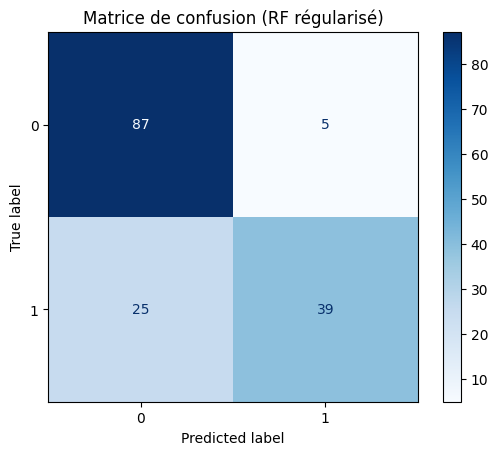

              precision    recall  f1-score   support

           0       0.78      0.95      0.85        92
           1       0.89      0.61      0.72        64

    accuracy                           0.81       156
   macro avg       0.83      0.78      0.79       156
weighted avg       0.82      0.81      0.80       156



In [10]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(pipe_reg, X_test, y_test, cmap="Blues")
plt.title("Matrice de confusion (RF régularisé)")
plt.show()
print(classification_report(y_test, pipe_reg.predict(X_test)))

## 6. Sérialisation du pipeline entier
On sauvegarde **tout le pipeline** (prétraitement + modèle), pas seulement le modèle : l'API reçoit des données brutes et le pipeline applique exactement le même prétraitement qu'à l'entraînement.

In [11]:
import os, pickle

final_pipe = pipe_reg
os.makedirs("model", exist_ok=True)
with open("model/titanic_pipeline.pkl", "wb") as f:
    pickle.dump(final_pipe, f)

print("Taille du fichier :", round(os.path.getsize("model/titanic_pipeline.pkl") / 1024, 1), "Ko")

Taille du fichier : 841.2 Ko


## 7. Rechargement et test sur des données brutes

In [12]:
with open("model/titanic_pipeline.pkl", "rb") as f:
    loaded = pickle.load(f)

tests = pd.DataFrame([
    {"Pclass": 1, "Sex": "female", "Age": 29,     "SibSp": 0, "Parch": 0, "Fare": 80.0, "Embarked": "C"},
    {"Pclass": 3, "Sex": "male",   "Age": 22,     "SibSp": 1, "Parch": 0, "Fare": 7.25, "Embarked": "S"},
    {"Pclass": 2, "Sex": "female", "Age": np.nan, "SibSp": 0, "Parch": 1, "Fare": 20.0, "Embarked": "S"},  # Age manquant
])
tests["P(survie)"] = loaded.predict_proba(tests)[:, 1].round(3)
tests["prediction"] = loaded.predict(tests.drop(columns="P(survie)"))
tests

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,P(survie),prediction
0,1,female,29.0,0,0,80.00,C,0.981,1
1,3,male,22.0,1,0,7.25,S,0.113,0
2,2,female,NaN,0,1,20.00,S,0.863,1


La 3e ligne a un `Age` manquant : l'imputer du pipeline le remplace par la médiane apprise sur le train, sans code supplémentaire.

**Remarques**
- `pickle.load` doit se faire avec la **même version de scikit-learn** que l'entraînement.
- Ne jamais charger un pickle dont on ne connaît pas l'origine (exécution de code arbitraire possible).

Étape suivante : `core.py` charge ce fichier et les APIs Flask / FastAPI l'exposent.